## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [11]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [12]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')
        
root_path = 'fmnist'
mkdir(root_path)

Directory fmnist already exists!


In [13]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path, 
                                                        train=True, 
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path, 
                                                       train=False, 
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

In [14]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [15]:
len(fmnist_dataset_test)

10000

In [16]:
for img, label in train_loader:
    print(img.shape)
    # print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [17]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here  

            nn.Linear(input_shape, input_shape // 2),
            nn.BatchNorm1d(input_shape // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 2, input_shape // 4),
            nn.BatchNorm1d(input_shape // 4),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 4, num_classes)
            )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [18]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 392]         307,720
       BatchNorm1d-3                  [-1, 392]             784
              ReLU-4                  [-1, 392]               0
           Dropout-5                  [-1, 392]               0
            Linear-6                  [-1, 196]          77,028
       BatchNorm1d-7                  [-1, 196]             392
              ReLU-8                  [-1, 196]               0
           Dropout-9                  [-1, 196]               0
           Linear-10                   [-1, 10]           1,970
Total params: 387,894
Trainable params: 387,894
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 1.48
Estimated T

Your experiments come here:

In [19]:
from sklearn.metrics import accuracy_score

model = TinyNeuralNetwork().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_func = nn.CrossEntropyLoss()

n_epoch = 10

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()

        outputs = model(xb)
        loss = loss_func(outputs, yb)
        loss.backward()

        opt.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = loss_func(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_acc = accuracy_score(all_targets, all_preds)

    print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/10, Train Loss: 0.5321, Val Loss: 0.4014, Val Acc: 0.8563
Epoch 2/10, Train Loss: 0.3919, Val Loss: 0.3995, Val Acc: 0.8549
Epoch 3/10, Train Loss: 0.3566, Val Loss: 0.3514, Val Acc: 0.8741
Epoch 4/10, Train Loss: 0.3350, Val Loss: 0.3501, Val Acc: 0.8739
Epoch 5/10, Train Loss: 0.3169, Val Loss: 0.3384, Val Acc: 0.8765
Epoch 6/10, Train Loss: 0.3042, Val Loss: 0.3392, Val Acc: 0.8776
Epoch 7/10, Train Loss: 0.2933, Val Loss: 0.3282, Val Acc: 0.8802
Epoch 8/10, Train Loss: 0.2836, Val Loss: 0.3233, Val Acc: 0.8820
Epoch 9/10, Train Loss: 0.2743, Val Loss: 0.3131, Val Acc: 0.8864
Epoch 10/10, Train Loss: 0.2639, Val Loss: 0.3076, Val Acc: 0.8908


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [ ]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(input_shape, input_shape // 2),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 2, input_shape // 4),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 4, input_shape // 8),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 8, input_shape // 16),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 16, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [21]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 392]         307,720
              ReLU-3                  [-1, 392]               0
            Linear-4                  [-1, 196]          77,028
              ReLU-5                  [-1, 196]               0
            Linear-6                   [-1, 10]           1,970
Total params: 386,718
Trainable params: 386,718
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 1.48
Estimated Total Size (MB): 1.49
----------------------------------------------------------------


In [30]:
model = OverfittingNeuralNetwork().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_func = nn.CrossEntropyLoss()

epoch_train_loss_list = []
epoch_val_loss_list = []
val_acc_list = []
n_epoch = 100

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()
        outputs = model(xb)

        loss = loss_func(outputs, yb)
        loss.backward()
        opt.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)

            loss = loss_func(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        val_acc = accuracy_score(all_targets, all_preds)

        print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_acc:.4f}")

        epoch_train_loss_list.append(epoch_train_loss)
        epoch_val_loss_list.append(epoch_val_loss)
        val_acc_list.append(val_acc)

Epoch 1/100, Train Loss: 0.8251, Val Loss: 0.5297, Val Acc: 0.8150
Epoch 2/100, Train Loss: 0.4726, Val Loss: 0.4820, Val Acc: 0.8284
Epoch 3/100, Train Loss: 0.4181, Val Loss: 0.4360, Val Acc: 0.8449
Epoch 4/100, Train Loss: 0.3841, Val Loss: 0.4326, Val Acc: 0.8412
Epoch 5/100, Train Loss: 0.3660, Val Loss: 0.3887, Val Acc: 0.8598
Epoch 6/100, Train Loss: 0.3438, Val Loss: 0.3852, Val Acc: 0.8628
Epoch 7/100, Train Loss: 0.3308, Val Loss: 0.3662, Val Acc: 0.8705
Epoch 8/100, Train Loss: 0.3179, Val Loss: 0.3561, Val Acc: 0.8714
Epoch 9/100, Train Loss: 0.3037, Val Loss: 0.3627, Val Acc: 0.8718
Epoch 10/100, Train Loss: 0.2925, Val Loss: 0.3594, Val Acc: 0.8718
Epoch 11/100, Train Loss: 0.2833, Val Loss: 0.3473, Val Acc: 0.8754
Epoch 12/100, Train Loss: 0.2765, Val Loss: 0.3360, Val Acc: 0.8784
Epoch 13/100, Train Loss: 0.2685, Val Loss: 0.3372, Val Acc: 0.8785
Epoch 14/100, Train Loss: 0.2619, Val Loss: 0.3362, Val Acc: 0.8789
Epoch 15/100, Train Loss: 0.2523, Val Loss: 0.3288, Val A

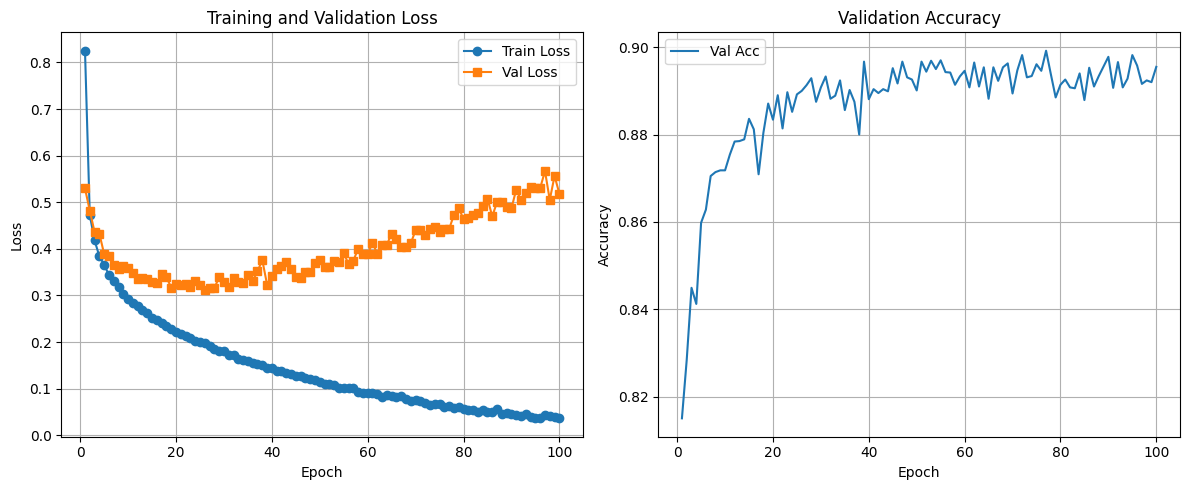

In [32]:
# Построение графиков потерь
plt.figure(figsize=(12, 5))

# График 1: Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epoch+1), epoch_train_loss_list, label='Train Loss', marker='o')
plt.plot(range(1, n_epoch+1), epoch_val_loss_list, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epoch+1), val_acc_list, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results. 

In [ ]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)

In [ ]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 10]           7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [ ]:
model = FixedNeuralNetwork().to(device)
opt = # YOUR CODE HERE
loss_func = # YOUR CODE HERE

# Your experiments, come here

SyntaxError: invalid syntax (2188921326.py, line 2)

### Conclusions:
_Write down small report with your conclusions and your ideas._